In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA 1.1**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

Solución sin IA:

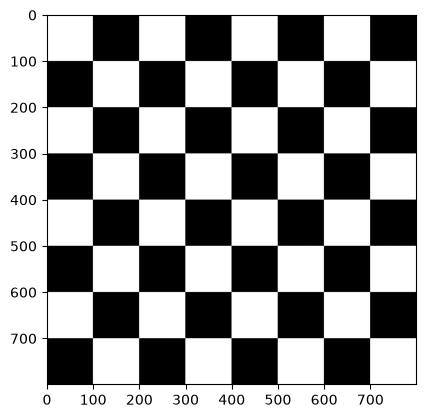

In [ ]:
#Imagen con fondo negro de medida 800x800
medida = 800
img_tarea = np.zeros((medida,medida,1), dtype = np.uint8)

for i in range(8):
        for j in range(8):
                #Pintar un cuadrado blanco en donde la suma de i+j sea par
                if((i+j)%2==0):
                        img_tarea[100*i:100*(i+1),100*j:100*(j+1)] = 255

plt.imshow(img_tarea, cmap='gray',vmin=0, vmax=255)
plt.show()

Solución con IA:

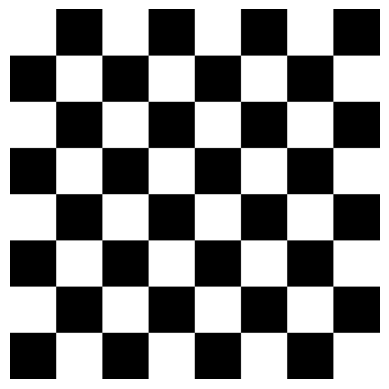

In [ ]:
tamano = 800
tablero = np.ones((tamano, tamano), dtype=np.uint8) * 255
casilla = tamano // 8
for fila in range(8):
    for columna in range(8):
        # Casillas negras
        if (fila + columna) % 2 == 1:
            tablero[
                fila * casilla:(fila + 1) * casilla,
                columna * casilla:(columna + 1) * casilla
            ] = 0

plt.imshow(tablero, cmap='gray')
plt.axis('off')
plt.show()

**TAREA 1.2**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

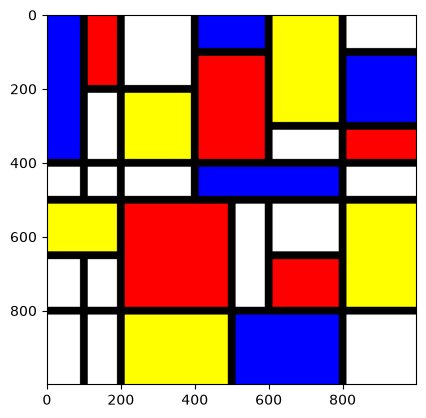

In [ ]:
ancho=1000
alto=1000

#Imagen creada con 1's y multiplicada por 255 para obtener un fondo blanco
imagen_mondrian = np.ones((alto,ancho,3), dtype = np.uint8) *255

#Rectangulos
cv2.rectangle(imagen_mondrian,(0,0),(100,400),(0,0,255),-1)
cv2.rectangle(imagen_mondrian,(100,0),(200,200),(255,0,0),-1)
cv2.rectangle(imagen_mondrian,(200,200),(400,400),(255,255,0),-1)
cv2.rectangle(imagen_mondrian,(400,100),(600,400),(255,0,0),-1)
cv2.rectangle(imagen_mondrian,(400,0),(600,100),(0,0,255),-1)
cv2.rectangle(imagen_mondrian,(600,0),(800,300),(255,255,0),-1)
cv2.rectangle(imagen_mondrian,(400,400),(800,500),(0,0,255),-1)
cv2.rectangle(imagen_mondrian,(800,300),(1000,400),(255,0,0),-1)
cv2.rectangle(imagen_mondrian,(800,100),(1000,300),(0,0,255),-1)
cv2.rectangle(imagen_mondrian,(200,500),(500,800),(255,0,0),-1)
cv2.rectangle(imagen_mondrian,(200,800),(500,1000),(255,255,0),-1)
cv2.rectangle(imagen_mondrian,(500,800),(800,1000),(0,0,255),-1)
cv2.rectangle(imagen_mondrian,(600,650),(800,800),(255,0,0),-1)
cv2.rectangle(imagen_mondrian,(800,500),(1000,800),(255,255,0),-1)
cv2.rectangle(imagen_mondrian,(0,500),(200,650),(255,255,0),-1)

#Horizontales
cv2.line(imagen_mondrian,(0,400),(1000,400),(0,0,0),20)
cv2.line(imagen_mondrian,(0,500),(1000,500),(0,0,0),20)
cv2.line(imagen_mondrian,(0,800),(1000,800),(0,0,0),20)
cv2.line(imagen_mondrian,(100,200),(400,200),(0,0,0),20)
cv2.line(imagen_mondrian,(600,300),(1000,300),(0,0,0),20)
cv2.line(imagen_mondrian,(400,100),(600,100),(0,0,0),20)
cv2.line(imagen_mondrian,(800,100),(1000,100),(0,0,0),20)
cv2.line(imagen_mondrian,(0,650),(200,650),(0,0,0),20)
cv2.line(imagen_mondrian,(600,650),(800,650),(0,0,0),20)

#Verticales
cv2.line(imagen_mondrian,(100,0),(100,500),(0,0,0),20)
cv2.line(imagen_mondrian,(100,650),(100,1000),(0,0,0),20)
cv2.line(imagen_mondrian,(200,0),(200,1000),(0,0,0),20)
cv2.line(imagen_mondrian,(400,0),(400,500),(0,0,0),20)
cv2.line(imagen_mondrian,(500,500),(500,1000),(0,0,0),20)
cv2.line(imagen_mondrian,(600,0),(600,400),(0,0,0),20)
cv2.line(imagen_mondrian,(600,500),(600,800),(0,0,0),20)
cv2.line(imagen_mondrian,(800,0),(800,1000),(0,0,0),20)

plt.imshow(imagen_mondrian) 
plt.show()


**TAREA 1.3**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
vid = cv2.VideoCapture(0)
while True:
    
    # Capturamos un fotograma de la cámara
    ret, frame = vid.read()
    
    # Obtenemos el alto, ancho y número de canales de la imagen
    alto, ancho, canal = frame.shape
    
    # Valores iniciales de los pixeles mas claros y mas oscuros
    Mas_claro = 0
    Mas_oscuro = 765
    
    # Recorremos todos los píxeles del fotograma
    for y in range(alto):
        for x in range(ancho):
            pixel = frame[y,x]
            
            #Cálculo de la claridad del pixel
            claridad = int(pixel[0]) + int(pixel[1]) + int(pixel[2])
            
            #Actualización de los valores en caso de aceptar la condición
            if claridad > Mas_claro:
                Mas_claro = claridad
                x_claro = x
                y_claro = y
            if claridad < Mas_oscuro:
                Mas_oscuro = claridad
                x_oscuro = x
                y_oscuro = y
    
    # Se pintan los circulos correspondientes, rodeando la zona más clara y más oscura
    # El circulo rojo representa la zona clara y el azul la zona oscura
    
    cv2.circle(frame, (x_claro, y_claro), 10, (0, 0, 255), 2)
    cv2.circle(frame, (x_oscuro, y_oscuro), 10, (255, 0, 0), 2)
    cv2.imshow('Cam', frame)
    if cv2.waitKey(20) == 27:
        break
    
vid.release()
cv2.destroyAllWindows()

**TAREA 1.4**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [5]:
vid = cv2.VideoCapture(0)

# definimos los colores (BGR)
color_sombra = [200, 40, 40]        # Azul
color_oscuro = [0, 0, 255]          # Rojo
color_claro = [255, 200, 100]       # Azul claro
color_luz = [200, 200, 200]         # gris

while True:      
    ret, frame = vid.read()
    if not ret:
        break

    # reducimos el tamaño
    h, w, c= frame.shape
    down_frame = cv2.resize(frame, (w // 2, h // 2))
    
    # pasamos a escala de grises
    gris = down_frame[:, :, 1]
    
    # lienzo vacío del mismo tamaño y 3 canales para pintar encima
    pop_art = np.zeros_like(down_frame)
    
    #asignamos colores según el nivel de gris (de 0 a 255)
    pop_art[gris < 60] = color_sombra
    pop_art[(gris >= 60) & (gris < 125)] = color_oscuro
    pop_art[(gris >= 125) & (gris < 190)] = color_claro
    pop_art[gris >= 190] = color_luz
    
    cv2.imshow('Pop Art', pop_art)
    
    # Salimos con esc
    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()